# EDA 01 — Selección de variables por correlación de Spearman


Análisis exploratorio orientado a la selección de variables sobre `matriz_nucleo.csv` (133 columnas).

## Índice

- **0.** Configuración, carga y frontera temporal
- **1.** Ranking crudo vs. ranking honesto
- **2.** Estabilidad del ranking entre años
- **3.** Relevancia por hora del día
- **4.** Redundancia: clustering jerárquico
- **5.** Conclusiones y conjunto seleccionado

## Por qué Spearman

El precio spot tiene colas gruesas, horas a cero y horas negativas desde 2024. Spearman trabaja sobre **rangos**: solo le importa si la relación es monótona, no su forma ni la escala.

El coste es que no detecta relaciones no monótonas — la temperatura sube el precio tanto con frío como con calor, y eso da rho ≈ 0 pese a ser predictiva. Es una limitación que hay que tener presente al leer los resultados.

---
## 0. Configuración, carga y frontera temporal

In [15]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 150)

In [16]:
# ------------------------------------------------- RAIZ DEL PROYECTO
# Sube desde el directorio actual hasta la carpeta del proyecto, de modo
# que el notebook funcione desde cualquier subcarpeta y en cualquier equipo.
def raiz_proyecto(nombre="edev_models"):
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if c.name == nombre:
            return c
    raise FileNotFoundError(f"'{nombre}' no está en los padres de {p}")

ROOT = raiz_proyecto()
os.chdir(ROOT)

RUTA_MATRIZ = ROOT / "data" / "gold" / "matriz_nucleo.csv"
RUTA_COLS   = next(p for p in [ROOT / "data" / "gold" / "matriz_nucleo_columnas.csv",
                               ROOT / "matriz_nucleo_columnas.csv"] if p.exists())
OUT =  ROOT / "eda" / "EDA_spearman_output"
OUT.mkdir(parents=True, exist_ok=True)

print("Raíz: ", ROOT)
print("Matriz:", RUTA_MATRIZ.exists(), "| Columnas:", RUTA_COLS.name)

Raíz:  C:\Users\Powan\Desktop\Maestria\TFM\edev_models
Matriz: True | Columnas: matriz_nucleo_columnas.csv


In [17]:
# ------------------------------------------------- CLAVES
TARGET, FECHA, HORA = "target_price", "fecha_objetivo", "hora"
NO_FEATURES = {"fecha_pred", "fecha_objetivo", "ts", "split", TARGET}

# ------------------------------------------------- CORTE TEMPORAL
# 2026 es el conjunto de test: se abre UNA vez, con el modelo ya elegido.
# Calcular correlaciones sobre 2026 ya sería mirar el test.
CORTE_TRAIN_VAL = "2025-12-31"

TOP_N = 30
UMBRAL_CLUSTER = 0.30   # variables con |rho| > 0.70 entre sí van al mismo grupo

### La frontera temporal condiciona todo el ejercicio

El mercado diario **casa a las 12:00 de la víspera**. Cualquier variable cuya fuente publique después de las 11:00 del día anterior es información del futuro: infla el ranking y falsea el MAE.

En la matriz hay tres grupos problemáticos:

| Grupo | Ejemplo | Problema |
|---|---|---|
| `casacion PDBC`, `programa PBF` con sufijo `_D` | `pdbc_ccgt_mw_D` | El PBF del día objetivo sale a las 13:45 |
| Precios europeos `_D` | `fr_entsoe_D` | Casan **simultáneamente** con MIBEL a las 12:00 |
| `es_esios_D` | — | Es el propio precio del día objetivo |

Con desfase de un día (`_Dm1`, `_Dm6`) todas estas fuentes sí son válidas.

**No las eliminamos silenciosamente:** las etiquetamos y calculamos el ranking dos veces. El contraste entre ambos es un resultado en sí mismo — mide cuánto de la aparente capacidad predictiva de la matriz es en realidad fuga de información.

In [18]:
BLOQUES_FRONTERA      = {"casacion PDBC", "programa PBF"}
VAR_TARGET_DISFRAZADO = {"es_esios_D"}
VAR_SIMULTANEAS       = {"pt_entsoe_D", "fr_entsoe_D", "de_lu_entsoe_D",
                         "it_nord_entsoe_D", "pl_entsoe_D",
                         "spread_es_pt_D", "spread_es_fr_D", "spread_es_de_D"}

def clasificar_frontera(var, bloque):
    if var in VAR_TARGET_DISFRAZADO:
        return "TARGET disfrazado"
    if bloque in BLOQUES_FRONTERA:
        return "POSTERIOR (no usable)"
    if var in VAR_SIMULTANEAS:
        return "SIMULTANEA (casa a las 12:00)"
    return "OK (pre-11:00)"

In [19]:
df   = pd.read_csv(RUTA_MATRIZ, parse_dates=[FECHA])
meta = pd.read_csv(RUTA_COLS).set_index("variable")

n0 = len(df)
df = df[df[FECHA] <= CORTE_TRAIN_VAL].sort_values(FECHA).reset_index(drop=True)
print(f"Filas: {n0:,} -> {len(df):,} tras cortar en {CORTE_TRAIN_VAL}")
print(f"Rango: {df[FECHA].min().date()} a {df[FECHA].max().date()}")
print(f"Nulos totales: {df.isna().sum().sum()}")

features = [c for c in df.columns
            if c not in NO_FEATURES and pd.api.types.is_numeric_dtype(df[c])]
print(f"\n{len(features)} features numéricas candidatas")

Filas: 57,521 -> 52,434 tras cortar en 2025-12-31
Rango: 2020-01-08 a 2025-12-31
Nulos totales: 0

128 features numéricas candidatas


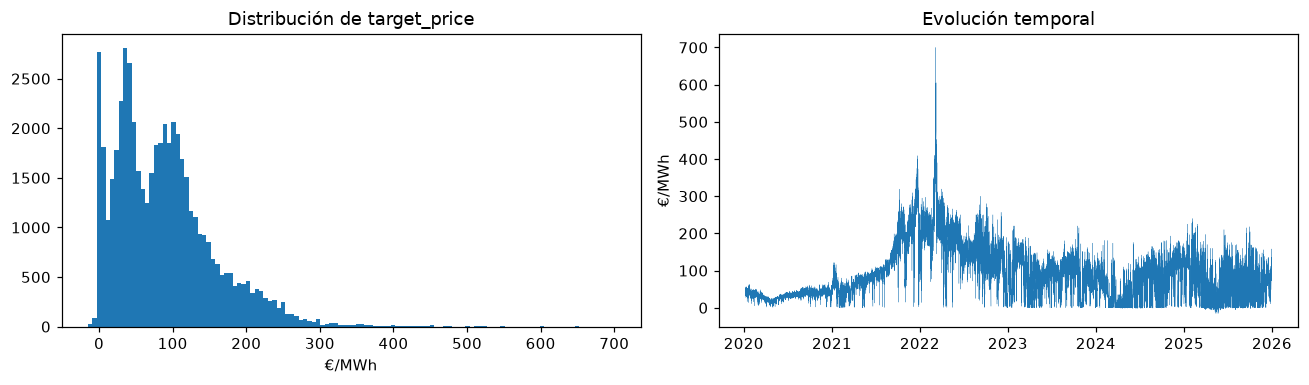

Horas con precio negativo: 782 (1.49%)
Horas con precio cero:     893 (1.70%)
Asimetría: 1.24   Curtosis: 2.89


In [20]:
# Distribución del objetivo: justifica el uso de Spearman
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(df[TARGET], bins=120, color="#1f77b4")
axes[0].set_title("Distribución de target_price"); axes[0].set_xlabel("€/MWh")
axes[1].plot(df[FECHA], df[TARGET], lw=0.2, color="#1f77b4")
axes[1].set_title("Evolución temporal"); axes[1].set_ylabel("€/MWh")
plt.tight_layout(); plt.show()

neg, cero = (df[TARGET] < 0).sum(), (df[TARGET] == 0).sum()
print(f"Horas con precio negativo: {neg} ({neg/len(df):.2%})")
print(f"Horas con precio cero:     {cero} ({cero/len(df):.2%})")
print(f"Asimetría: {df[TARGET].skew():.2f}   Curtosis: {df[TARGET].kurtosis():.2f}")

---
## 1. Ranking crudo vs. ranking honesto

In [21]:
def ranking_spearman(df, features):
    filas, y = [], df[TARGET].values
    for f in features:
        x = df[f].values
        if np.nanstd(x) == 0:
            rho, p = np.nan, np.nan
        else:
            rho, p = spearmanr(x, y, nan_policy="omit")
        bloque = meta.loc[f, "bloque"] if f in meta.index else "desconocido"
        filas.append({
            "variable": f, "bloque": bloque,
            "origen": meta.loc[f, "tabla_origen"] if f in meta.index else "",
            "rho": rho, "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
            "p_valor": p, "n_unicos": df[f].nunique(),
            "frontera": clasificar_frontera(f, bloque),
        })
    r = pd.DataFrame(filas).sort_values("abs_rho", ascending=False)
    # Con ~50k observaciones casi todo sale significativo: el p-valor no
    # discrimina. Lo que importa es el TAMAÑO del efecto.
    r["signif_pero_irrelevante"] = (r["p_valor"] < 0.01) & (r["abs_rho"] < 0.05)
    return r

rank = ranking_spearman(df, features)
rank.to_csv(OUT / "ranking_spearman.csv", index=False)

print(rank.groupby("frontera")["abs_rho"].agg(["count", "median", "max"]).round(3))
print(f"\nSignificativas pero irrelevantes (p<0.01 y |rho|<0.05): "
      f"{rank['signif_pero_irrelevante'].sum()}")

                               count  median    max
frontera                                           
OK (pre-11:00)                    89   0.104  0.813
POSTERIOR (no usable)             30   0.155  0.499
SIMULTANEA (casa a las 12:00)      8   0.615  0.883
TARGET disfrazado                  1   0.883  0.883

Significativas pero irrelevantes (p<0.01 y |rho|<0.05): 21


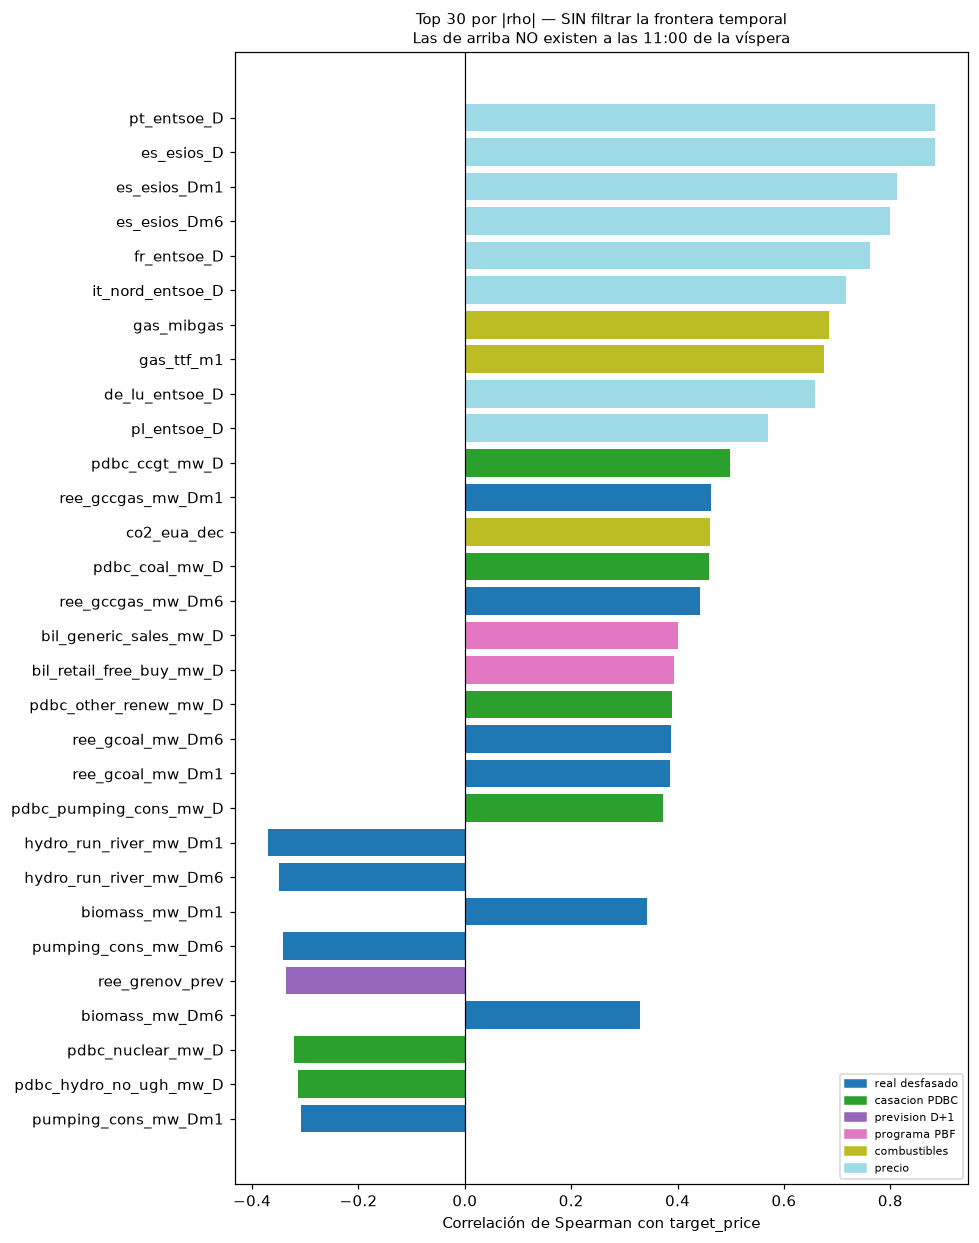

In [22]:
def plot_top(r, titulo, fname, n=TOP_N):
    sub = r.dropna(subset=["abs_rho"]).head(n).iloc[::-1]
    bloques = sub["bloque"].unique()
    cmap = dict(zip(bloques, plt.cm.tab20(np.linspace(0, 1, len(bloques)))))
    fig, ax = plt.subplots(figsize=(9, 0.32 * len(sub) + 1.8))
    ax.barh(sub["variable"], sub["rho"], color=[cmap[b] for b in sub["bloque"]])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Correlación de Spearman con target_price")
    ax.set_title(titulo, fontsize=10)
    ax.legend([plt.Rectangle((0,0),1,1, color=cmap[b]) for b in bloques],
              bloques, fontsize=7, loc="lower right")
    plt.tight_layout(); plt.savefig(OUT / fname, dpi=150); plt.show()

plot_top(rank,
         "Top 30 por |rho| — SIN filtrar la frontera temporal\n"
         "Las de arriba NO existen a las 11:00 de la víspera",
         "01a_ranking_crudo.png")

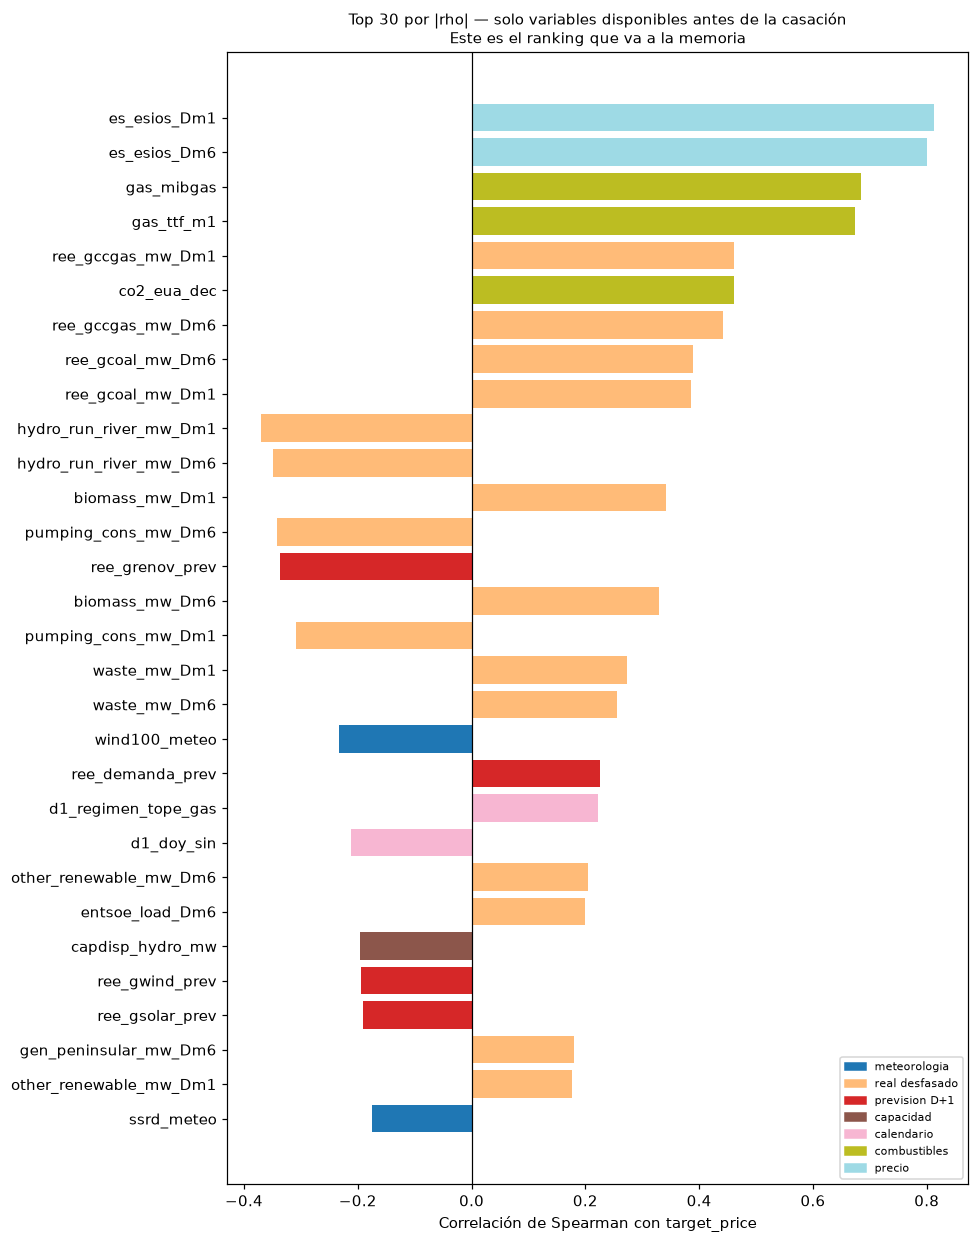

Top 10 legítimas:
              variable         bloque       rho
          es_esios_Dm1         precio  0.813348
          es_esios_Dm6         precio  0.800191
            gas_mibgas   combustibles  0.685226
            gas_ttf_m1   combustibles  0.674461
     ree_gccgas_mw_Dm1 real desfasado  0.462030
           co2_eua_dec   combustibles  0.460774
     ree_gccgas_mw_Dm6 real desfasado  0.441267
      ree_gcoal_mw_Dm6 real desfasado  0.388459
      ree_gcoal_mw_Dm1 real desfasado  0.386135
hydro_run_river_mw_Dm1 real desfasado -0.370052


In [23]:
rank_ok = rank[rank["frontera"] == "OK (pre-11:00)"].copy()

plot_top(rank_ok,
         "Top 30 por |rho| — solo variables disponibles antes de la casación\n"
         "Este es el ranking que va a la memoria",
         "01b_ranking_frontera_ok.png")

print("Top 10 legítimas:")
print(rank_ok[["variable", "bloque", "rho"]].head(10).to_string(index=False))

**Interpretación.** La diferencia de magnitud entre ambos gráficos es el coste real de respetar la frontera. Si el ranking crudo alcanza |rho| > 0.9 y el honesto se queda en 0.5-0.7, eso no es un fracaso: es la medida de cuánto habría exagerado el modelo su rendimiento usando información no disponible.

Nota: *un modelo con MAE de 3 €/MWh que usa el PBF del día objetivo no tiene sentido.*

---
## 2. Estabilidad del ranking entre años

El mercado eléctrico español no ha sido el mismo sistema durante todo el histórico: crisis del gas de 2021-22, tope al gas (`d1_regimen_tope_gas`), expansión masiva de la fotovoltaica y aparición de precios negativos.

Si una variable domina en 2022 y es irrelevante en 2025, seleccionarla por el rho global es un error: se está optimizando para un régimen que ya no existe.

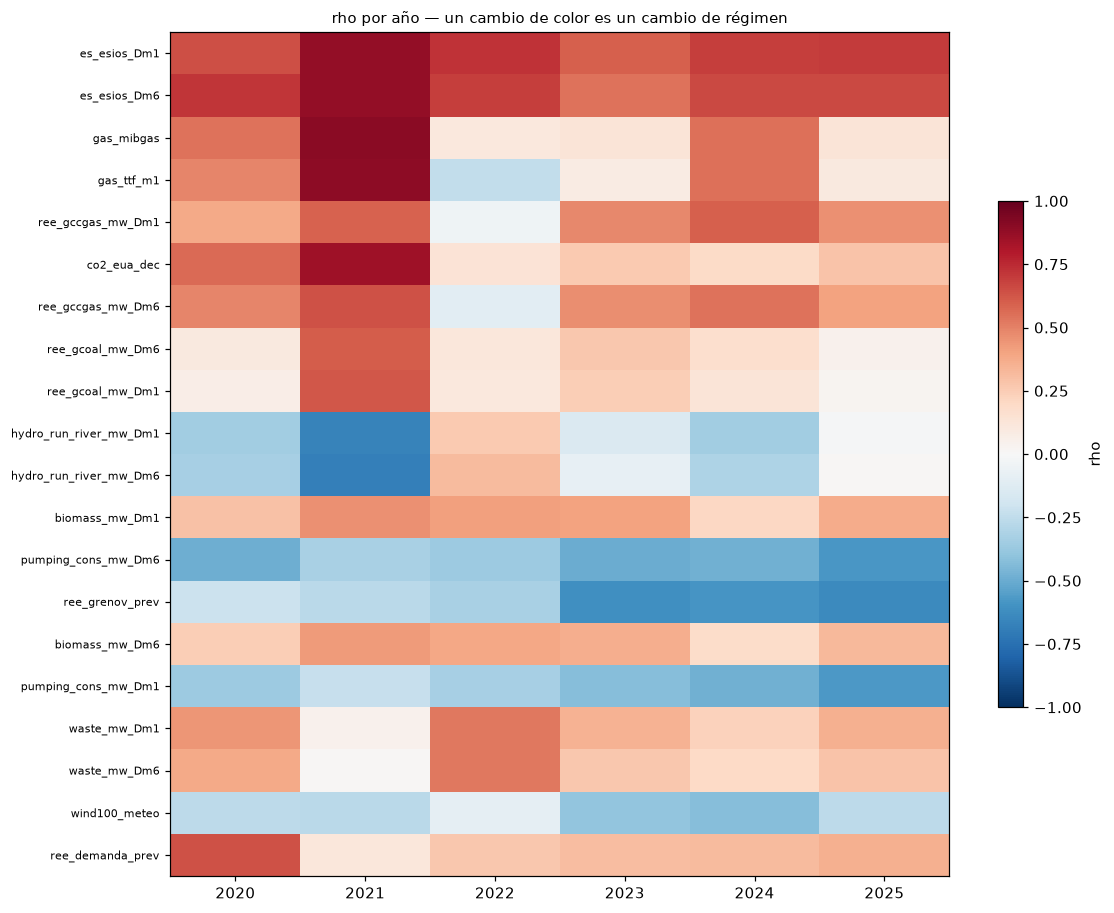

Variables MENOS estables (mayor rango entre años):
gas_ttf_m1                1.142
hydro_run_river_mw_Dm6    1.001
hydro_run_river_mw_Dm1    0.935
gas_mibgas                0.794
ree_gccgas_mw_Dm6         0.736
co2_eua_dec               0.717
ree_gccgas_mw_Dm1         0.642
ree_gcoal_mw_Dm1          0.589
Name: rango, dtype: float64


In [24]:
top_vars = rank_ok.dropna(subset=["abs_rho"]).head(20)["variable"].tolist()
años = sorted(df[FECHA].dt.year.unique())

M = pd.DataFrame(index=top_vars, columns=años, dtype=float)
for a in años:
    sub = df[df[FECHA].dt.year == a]
    if len(sub) < 500:
        continue
    for f in top_vars:
        if sub[f].nunique() >= 2:
            M.loc[f, a] = spearmanr(sub[f], sub[TARGET], nan_policy="omit")[0]

fig, ax = plt.subplots(figsize=(1.1*len(años)+4, 0.32*len(top_vars)+2))
im = ax.imshow(M.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(años))); ax.set_xticklabels(años)
ax.set_yticks(range(len(top_vars))); ax.set_yticklabels(top_vars, fontsize=7)
ax.set_title("rho por año — un cambio de color es un cambio de régimen", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.6, label="rho")
plt.tight_layout(); plt.savefig(OUT / "03_estabilidad_anual.png", dpi=150); plt.show()

M["rango"] = M.max(axis=1) - M.min(axis=1)
print("Variables MENOS estables (mayor rango entre años):")
print(M["rango"].sort_values(ascending=False).head(8).round(3))
M.to_csv(OUT / "estabilidad_anual.csv")

---
## 3. Relevancia por hora del día

El rho global promedia situaciones que no tienen nada que ver entre sí: la fotovoltaica manda a las 14h y es literalmente cero a las 4h.

Este gráfico responde a una decisión de diseño concreta: **¿modelo horario único con `hora` como feature, o 24 modelos separados?** Si la relevancia cambia mucho por hora, el modelo único necesita interacciones fuertes con `hora` — argumento a favor de boosting frente a lineales.

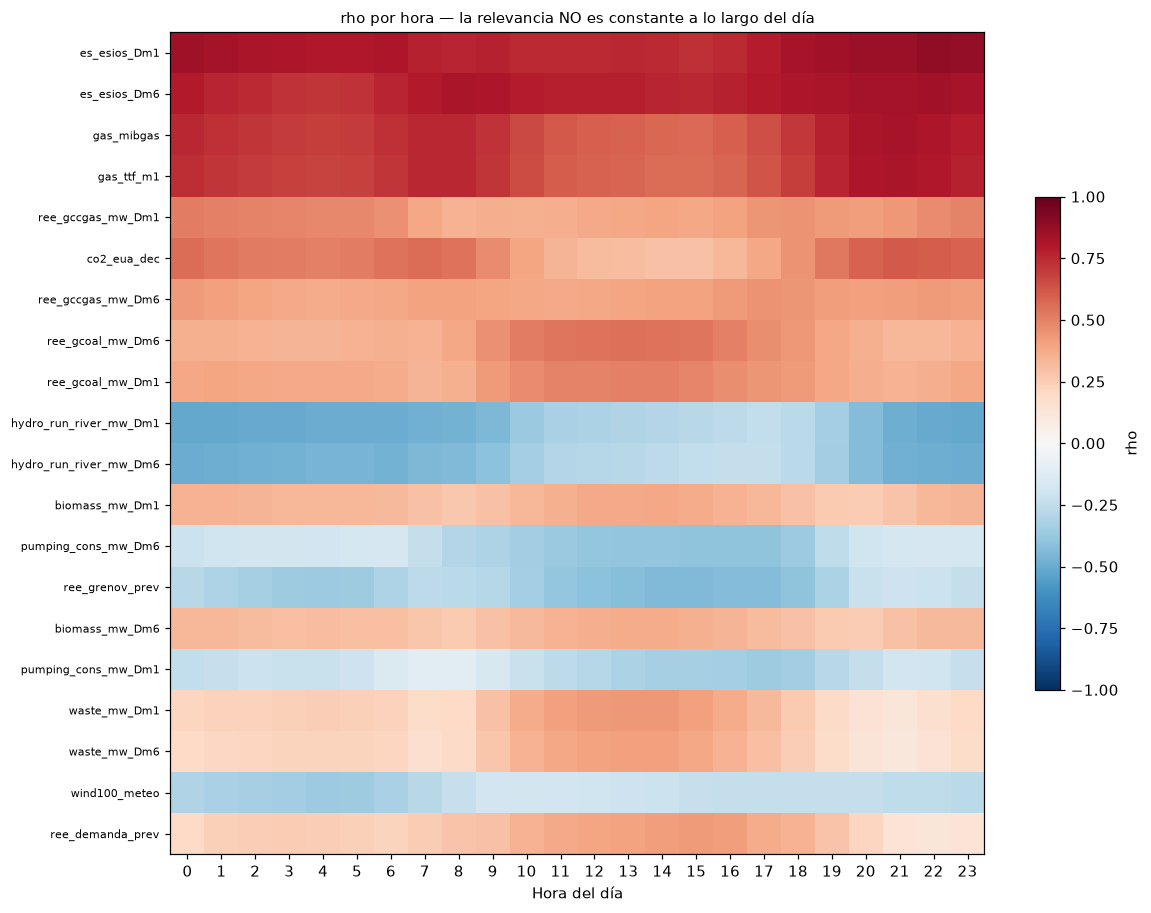

Mayor variación intradiaria (candidatas a interacción con hora):
co2_eua_dec               0.323
waste_mw_Dm1              0.313
ree_demanda_prev          0.307
waste_mw_Dm6              0.300
hydro_run_river_mw_Dm1    0.268
gas_ttf_m1                0.260
gas_mibgas                0.258
hydro_run_river_mw_Dm6    0.258
Name: amplitud, dtype: float64


In [25]:
horas = sorted(df[HORA].unique())
H = pd.DataFrame(index=top_vars, columns=horas, dtype=float)
for h in horas:
    sub = df[df[HORA] == h]
    for f in top_vars:
        if sub[f].nunique() >= 2:
            H.loc[f, h] = spearmanr(sub[f], sub[TARGET], nan_policy="omit")[0]

fig, ax = plt.subplots(figsize=(11, 0.32*len(top_vars)+2))
im = ax.imshow(H.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(horas))); ax.set_xticklabels(horas)
ax.set_yticks(range(len(top_vars))); ax.set_yticklabels(top_vars, fontsize=7)
ax.set_xlabel("Hora del día")
ax.set_title("rho por hora — la relevancia NO es constante a lo largo del día",
             fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.6, label="rho")
plt.tight_layout(); plt.savefig(OUT / "04_por_hora.png", dpi=150); plt.show()

H["amplitud"] = H.max(axis=1) - H.min(axis=1)
print("Mayor variación intradiaria (candidatas a interacción con hora):")
print(H["amplitud"].sort_values(ascending=False).head(8).round(3))
H.to_csv(OUT / "rho_por_hora.csv")

---
## 4. Redundancia: clustering jerárquico

Un ranking univariante ordena las variables pero no dice **cuáles sobran**. `wind_mw_Dm1`, `wind_mw_Dm6` y `ree_gwind_prev` son casi la misma señal.

Agrupamos por distancia $d = 1 - |\rho|$ y nos quedamos con un representante por grupo: el de mayor |rho| con el objetivo.

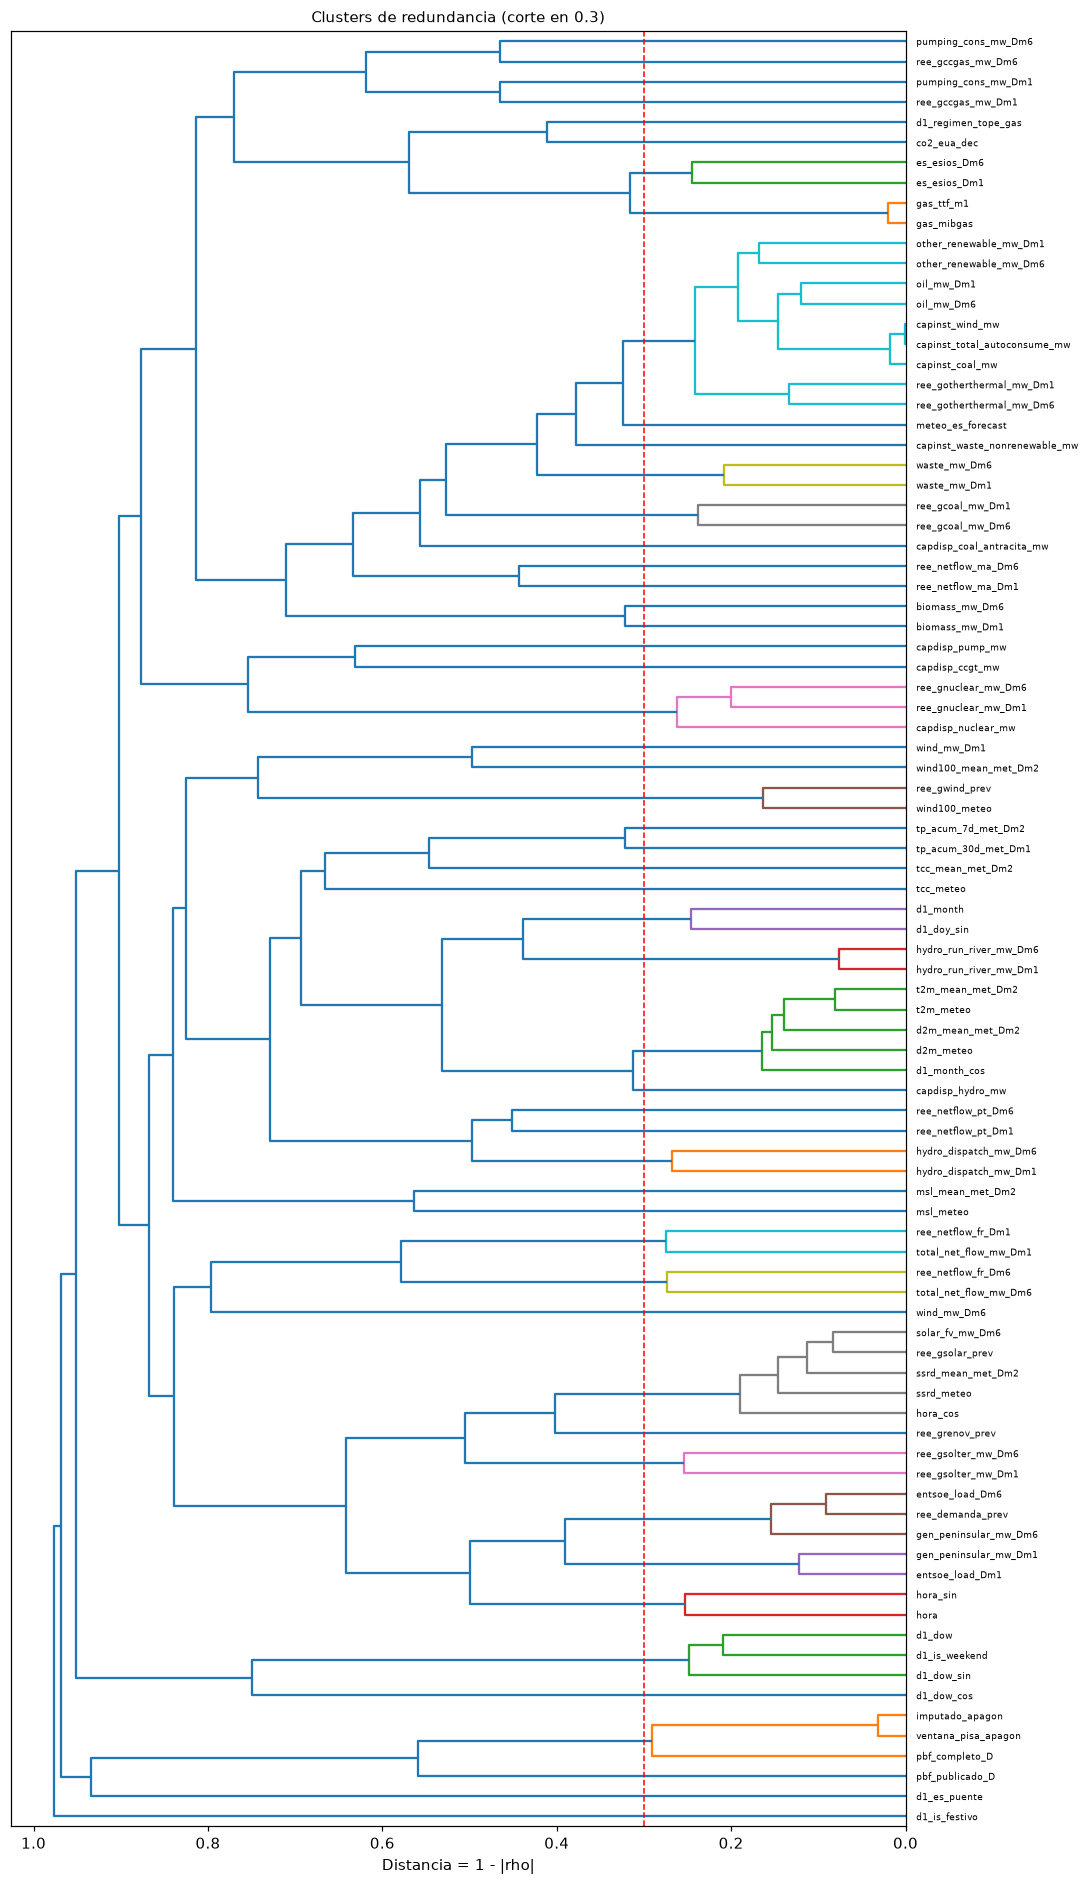

In [26]:
feats_ok = rank_ok["variable"].tolist()
rho_m = df[feats_ok].corr(method="spearman").fillna(0).values
dist = 1 - np.abs(rho_m)
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2          # forzar simetría exacta

Z = hierarchy.linkage(squareform(dist, checks=False), method="average")
labels = hierarchy.fcluster(Z, t=UMBRAL_CLUSTER, criterion="distance")

fig, ax = plt.subplots(figsize=(10, 0.16*len(feats_ok)+3))
hierarchy.dendrogram(Z, labels=feats_ok, orientation="left",
                     color_threshold=UMBRAL_CLUSTER, leaf_font_size=6, ax=ax)
ax.axvline(UMBRAL_CLUSTER, color="red", ls="--", lw=1)
ax.set_xlabel("Distancia = 1 - |rho|")
ax.set_title(f"Clusters de redundancia (corte en {UMBRAL_CLUSTER})", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "05_dendrograma.png", dpi=150); plt.show()

In [27]:
cl = pd.DataFrame({"variable": feats_ok, "cluster": labels}) \
       .merge(rank_ok[["variable","abs_rho","bloque","frontera"]], on="variable")
reps = cl.sort_values("abs_rho", ascending=False).groupby("cluster", as_index=False).first()

cl.to_csv(OUT / "clusters_completos.csv", index=False)
reps.to_csv(OUT / "representantes_cluster.csv", index=False)

print(f"{len(feats_ok)} variables -> {cl.cluster.nunique()} clusters "
      f"(reducción del {1-cl.cluster.nunique()/len(feats_ok):.0%})\n")
print("Clusters con más de una variable (redundancia detectada):")
for c, g in cl.groupby("cluster"):
    if len(g) > 1:
        elegida = g.sort_values("abs_rho", ascending=False).iloc[0]["variable"]
        resto = [v for v in g["variable"] if v != elegida]
        print(f"  [{elegida}]  absorbe -> {', '.join(resto)}")

89 variables -> 52 clusters (reducción del 42%)

Clusters con más de una variable (redundancia detectada):
  [ventana_pisa_apagon]  absorbe -> imputado_apagon, pbf_completo_D
  [d1_is_weekend]  absorbe -> d1_dow, d1_dow_sin
  [hora]  absorbe -> hora_sin
  [entsoe_load_Dm1]  absorbe -> gen_peninsular_mw_Dm1
  [ree_demanda_prev]  absorbe -> entsoe_load_Dm6, gen_peninsular_mw_Dm6
  [ree_gsolter_mw_Dm1]  absorbe -> ree_gsolter_mw_Dm6
  [ree_gsolar_prev]  absorbe -> ssrd_meteo, solar_fv_mw_Dm6, ssrd_mean_met_Dm2, hora_cos
  [total_net_flow_mw_Dm6]  absorbe -> ree_netflow_fr_Dm6
  [total_net_flow_mw_Dm1]  absorbe -> ree_netflow_fr_Dm1
  [hydro_dispatch_mw_Dm1]  absorbe -> hydro_dispatch_mw_Dm6
  [d2m_meteo]  absorbe -> d2m_mean_met_Dm2, t2m_meteo, d1_month_cos, t2m_mean_met_Dm2
  [hydro_run_river_mw_Dm1]  absorbe -> hydro_run_river_mw_Dm6
  [d1_doy_sin]  absorbe -> d1_month
  [wind100_meteo]  absorbe -> ree_gwind_prev
  [ree_gnuclear_mw_Dm1]  absorbe -> ree_gnuclear_mw_Dm6, capdisp_nuclear_m

---
## 5. Conclusiones y conjunto seleccionado

In [28]:
resumen = {
    "corte_temporal": CORTE_TRAIN_VAL,
    "n_features_inicial": len(features),
    "n_tras_frontera": len(feats_ok),
    "n_tras_clustering": len(reps),
    "descartadas_por_frontera": rank[rank.frontera != "OK (pre-11:00)"]["variable"].tolist(),
    "seleccion": reps.sort_values("abs_rho", ascending=False)["variable"].tolist(),
}
json.dump(resumen, open(OUT / "seleccion_spearman.json", "w"),
          indent=2, ensure_ascii=False)

print(f"{len(features)} features numéricas")
print(f"  -> {len(feats_ok)} tras la frontera temporal")
print(f"  -> {len(reps)} tras clustering de redundancia\n")
for i, v in enumerate(resumen["seleccion"], 1):
    rho = rank_ok.loc[rank_ok.variable == v, "rho"].iloc[0]
    print(f"  {i:2d}. {v:<34s} rho={rho:+.3f}")

128 features numéricas
  -> 89 tras la frontera temporal
  -> 52 tras clustering de redundancia

   1. es_esios_Dm1                       rho=+0.813
   2. gas_mibgas                         rho=+0.685
   3. ree_gccgas_mw_Dm1                  rho=+0.462
   4. co2_eua_dec                        rho=+0.461
   5. ree_gccgas_mw_Dm6                  rho=+0.441
   6. ree_gcoal_mw_Dm6                   rho=+0.388
   7. hydro_run_river_mw_Dm1             rho=-0.370
   8. biomass_mw_Dm1                     rho=+0.342
   9. pumping_cons_mw_Dm6                rho=-0.341
  10. ree_grenov_prev                    rho=-0.337
  11. biomass_mw_Dm6                     rho=+0.330
  12. pumping_cons_mw_Dm1                rho=-0.309
  13. waste_mw_Dm1                       rho=+0.274
  14. wind100_meteo                      rho=-0.234
  15. ree_demanda_prev                   rho=+0.226
  16. d1_regimen_tope_gas                rho=+0.221
  17. d1_doy_sin                         rho=-0.211
  18. other_renewab

### Lecturas que conviene dejar escritas en la memoria

**Un `abs_rho` cercano a cero no significa "inútil".** La temperatura sube el precio con frío *y* con calor: relación en U, rho ≈ 0, y aun así predictiva. Es el límite del filtro univariante y la razón de comprobarlo después con métodos multivariantes.

**El p-valor no discrimina aquí.** Con ~50.000 observaciones horarias prácticamente todo sale significativo; lo relevante es el tamaño del efecto.

**La frontera temporal es el resultado más vendible.** Cuantificar cuánto MAE se "gana" con variables no disponibles en producción, y renunciar a ello conscientemente, es el tipo de rigor que distingue un TFM de un trabajo de fin de módulo.

### Reparto de figuras

| Memoria | Anexo |
|---|---|
| 01b — ranking con frontera respetada | 01a — ranking crudo |
| 04 — heatmap por hora | 02 — poder por bloque |
| | 03 — estabilidad anual |
| | 05 — dendrograma |

### Salida

`representantes_cluster.csv` y `seleccion_spearman.json` son la entrada del notebook `EDA_02_SFS.ipynb`.